# Coursework Set Week 6

**Common remarks**:

* Deadline: Sunday at 23:59h for the week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Eszter B. Bartucz
* Username: ebbartucz
* Student number: s6362311
* Group (AS1, etc.): AS4

-----

In [ ]:
totalpoints = currentpoints = 0

### Exploring a HI data cube (7 pt) <font color='red'><b>COURSEWORK</b></font>
   
* Download FITS image [ngc6946.fits](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/ngc6946.fits)
* Create a mosaic with 5 rows and 10 columns of channel maps for the Z indices ``range(1, 101, 2)``
* Remove axis labeling with Axes methods ``set_xticklabels([])`` and ``set_yticklabels([])``.
* If you add two channel maps you get a new map where each pixel is the sum of the two maps. If you add all channel maps (not the noisy ones), you get a so called *total HI* map.

    * Select a suitable range of channel maps and sum them to get a total HI map. Make a plot of this map
    * Label the axes with the header values of ``CTYPE1`` and ``CTYPE2``.
    * Make a locatable colorbar and label its Y axis with the header value of ``BUNIT``. 
        
* A *position velocity* (PV) map is a slice through the data at one fixed spatial position. 
   It tells you something about how the velocities in a galaxy behave as function of position 
   and one fixed position.   
   In NumPy jargon a PV map can be an YZ slice or a XZ slice. 

    * Plot a PV map for a fixed Right Ascension (R.A.) with index 50.
    * Plot a vertical line at Dec. with index 40.
    * Label the axes with the header values of ``CTYPE2`` and ``CTYPE3``. <br>&nbsp;</br>
        
* A *global HI spectral profile* is a slice in along the spectral axis at a fixed Right Ascension and Declination.
   It is a 1D curve with intensities as function of frequency (or velocity). It shows you at which 
   velocity most of the gas is rotating in a galaxy given a position in R.A. and Dec.

    * Plot a global profile at R.A. with index 50 and Dec. with index 40.
    * Label the plot axes with the header values of ``CTYPE3`` and ``BUNIT``. <br>&nbsp;</br>

* What is the relation between this profile and the vertical line in the previous plot of the PV diagram?   

**Answers**:

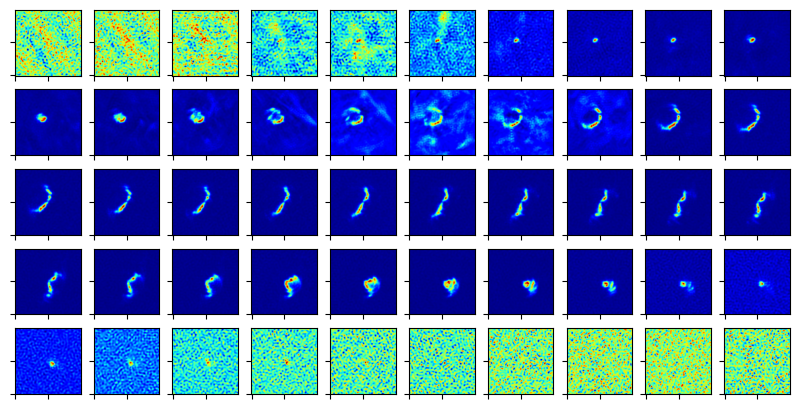

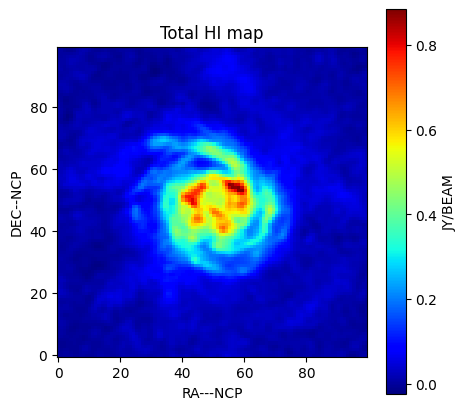

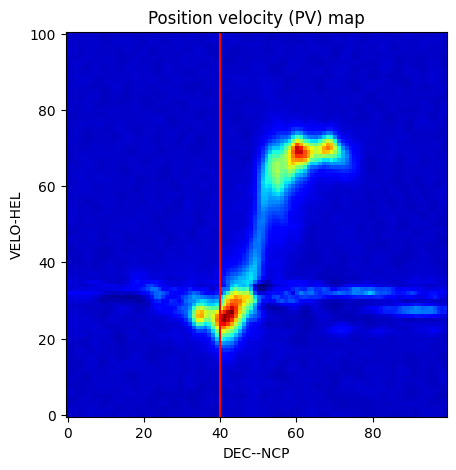

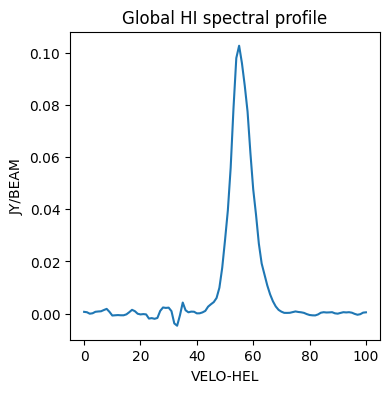

In [84]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

# Open the FITS file
file = fits.open('ngc6946.fits')
hdr = file[0].header

data = file[0].data  # the 0 extension contains the image data

fig = plt.figure(figsize = (10,5))
for i,Z in enumerate(range(1,101,2)): # i is the index of the data in the Z column, Z is the data in the Z column
    frame = fig.add_subplot(5,10,i+1) # making sure mosaic is 5 by 10 
    plt.imshow(data[Z,...], origin = 'lower', cmap = 'jet')
    frame.set_xticklabels([])
    frame.set_yticklabels([])
plt.show

#from the plot we can see that the noisy plots are 1-6 and the last 10. excluding them:

fig2 = plt.figure(figsize = (5,5))
frame2 = fig2.add_subplot(1,1,1)

datanew = 0
for i,Z in enumerate(range(13,81,2)):
    datanew += np.array(data[Z,...]) # summing the channel maps
    
plt.imshow(datanew, origin = 'lower', cmap = 'jet')
plt.colorbar(label = hdr['BUNIT'])
frame2.set_title('Total HI map')
frame2.set_xlabel(hdr['CTYPE1'])
frame2.set_ylabel(hdr['CTYPE2'])
plt.show()


#plotting a PV map for fixed RA, i.e fixed column:

fig3 = plt.figure(figsize = (5,5))
frame3 = fig3.add_subplot(1,1,1)
plt.imshow(data[:,50,:], origin = 'lower', cmap = 'jet')
frame3.axvline(40, color = 'red') # plotting the vertical line
frame3.set_title('Position velocity (PV) map')
frame3.set_xlabel(hdr['CTYPE2'])
frame3.set_ylabel(hdr['CTYPE3'])
plt.show()

fig4 = plt.figure(figsize = (4,4))
frame4 = fig4.add_subplot(1,1,1)
plt.plot(data[:,40,50])
frame4.set_title('Global HI spectral profile')
frame4.set_xlabel(hdr['CTYPE3'])
frame4.set_ylabel(hdr['BUNIT'])
plt.show()

#This profile is the intensity-velocity profile along the plotted vertical line.
#Basically we can imagine this vertical line as looking at the profile from the higher intensity direction
#i.e. the origin (0,0) of the profile plot is at (40,0) of the PV map and profile(100,0) is at PV(40,100).

In [ ]:
# Leave unaltered
totalpoints += 7
currentpoints += 0.0

### Galaxy Colour (5 pt) <font color='red'><b>COURSEWORK</b></font>
   
Download [SDSS_DR17_galaxies.fits](https://brightspace.rug.nl/content/enforced/457626-WBAS018-05.2025-2026.1/SDSS_DR17_galaxies.fits), which contains apparent magnitude in ``u, g, r, i, z`` five SDSS broad-band filters.

* Create a Pandas DataFrame from the FITS table.
* Filter out any data with negative values.
* Calculate every combination of colours from each broad band filter, e.g. u-g, u-r, u-i, u-z, g-r, ......
* Calculate the mean and standard deviation of the each colour.
* Use Object-Oriented Plotting to create a corner plot using derived colours.
* Set the xlim and ylim to be within three standard deviation.
* Add title for each histogram with information of the mean and standard deviation of each colour in the format of $\mu\pm\sigma$
 (to one decimal place).

[galaxy_colour.png](attachment:116628c6-fd70-44b6-b939-6d3dc84b26b1.png)
   
**Plot and answer**:

In [116]:
from astropy.io import fits
from astropy.table import Table
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Open the FITS file
file = fits.open('SDSS_DR17_galaxies.fits')
file.info()
# Access the data
data = file[1].data  # the first extension contains the table
hdr = file[1].header

colnames = file[1].columns.names # List of the column names
print(colnames)


dfdata = pd.DataFrame(data)
print(dfdata.head())

#filtering out any negative data:
masku = dfdata['u']>=0
maskg = dfdata['g']>=0
maskr = dfdata['r']>=0
maski = dfdata['i']>=0
maskz = dfdata['z']>=0

mask = masku & maskg & maskr & maski & maskz

dfdata = data[mask] # there were no negative values in the data

#creating new columns for color indexes:

hdr['u-r']=data['u']-data['r']
hdr['u-i']=data['u']-data['i']
hdr['u-z']=data['u']-data['z']
hdr['g-r']=data['g']-data['r']
hdr['g-i']=data['g']-data['i']
hdr['g-z']=data['g']-data['z']
hdr['r-i']=data['r']-data['i']
hdr['r-z']=data['r']-data['z']
hdr['i-z']=data['i']-data['z']

df.insert(len(columns),'u-g',data['u']-data['g'])





Filename: SDSS_DR17_galaxies.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU     20   10000R x 6C   [K, E, E, E, E, E]   
['ObjID', 'u', 'g', 'r', 'i', 'z']
                 ObjID          u          g          r          i          z
0  1237667429572346493  22.133240  22.190250  21.788059  21.355808  21.630119
1  1237665225699688707  21.623161  21.394985  20.979010  20.807341  21.209600
2  1237661849859391812  21.970703  21.247322  20.650488  20.399561  20.187206
3  1237655464310014355  21.850883  21.075569  20.600910  20.281101  20.171160
4  1237668332564316684  22.198875  21.121441  20.892130  20.848957  20.391762


ValueError: Illegal value: array([0.3451805, 0.6441517, 1.3202152, ..., 1.7547989, 1.3554649,
       1.2247543], dtype=float32).

In [ ]:
# Leave unaltered
totalpoints += 5
currentpoints += 0.0

### Astroquery: retrieving SDSS image and spectra (5 pt) <font color='red'><b>COURSEWORK</b></font>

Spiral galaxy M77 (NGC 1068) is a bright galaxy known for hosting an active galactic nucleus (AGN). With Astropy package, we construct M77's coordinate using the code below.

```python
from astropy import coordinates as coords

# Coordinates of M77
ra = 40.6696  # degrees
dec = -0.0133  # degrees
pos = coords.SkyCoord(ra, dec, unit="deg", frame="icrs")
```

* Use ``astroquery`` ([search regions](https://astroquery.readthedocs.io/en/latest/sdss/sdss.html#searching-regions-and-multiple-objects)) on the ``pos``, containing RA and DEC of this galaxy, to retrieve its SDSS spectrum using ``get_spectra()``. The search radius sets as ``10 arcsec`` for searching.
* The return object of ``get_spectra()`` is a list of [HDUList](https://docs.astropy.org/en/stable/io/fits/api/hdulists.html#astropy.io.fits.HDUList) objects.
* Retrieve flux and wavelengths using columns ``flux`` and ``loglam``. Note that the wavelength is in logarithmic value, you need to convert it back to a linear scale.
* The redshift of M77 is approximately ``z~0.0038``. Calculating the rest-frame wavelengths.
* Use Object-Oriented Plotting to plot:
    * a rest-frame spectrum which corrects the redshift effect (top)
    * a zoom-in spectrum at wavelength between 6450 and 6650 angstrom (bottom)
* Draw vertical lines for H$\alpha$ lines in both frames. Label them and show with legend.
* Draw vertical lines indicating approximately where the peak of the flux is, which in fact should be the H$\alpha$ line.
* An example plot is shown below.
* Calculating the velocity indicated by the difference between the two wavelengths.
* Share your thought using a markdown on what might be causing this offset. This question will not be graded, and meant to train a bit your scientific thinking. Feel free to express any thought.

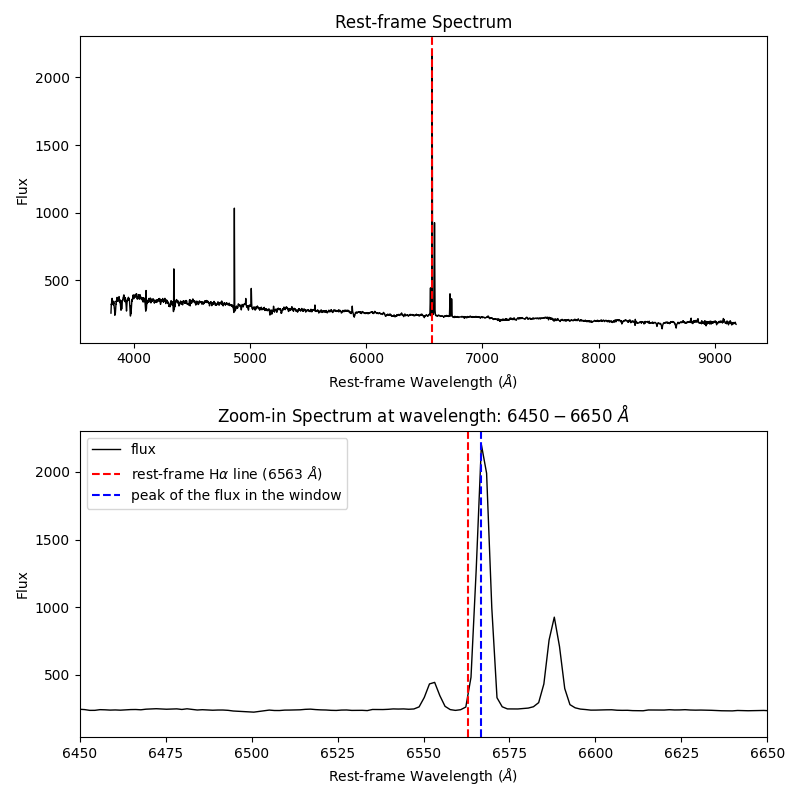

In [ ]:
# Leave unaltered
totalpoints += 5
currentpoints += 0.0

### Comparing an image in different color scales (stretches) (4pt) <font color='red'><b>COURSEWORK</b></font>

Given is the Blaauw observatory FITS file
[20210422_Li_.00000066.FIT](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/20210422_Li_.00000066.FIT)

Use the `imdisplay()` function from the notebook *The art of plotting an image* to make a mosaic with this image using all the different scales (stretches) available to that function. 

* Add a proper docstring to the function.
* Show the used scale in the title of the plot. (hints: tight_layout, fontsize).
* Also include the image without scaling as the first plot in the mosaic.

**Answer**:

In [ ]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Image stacking optical data (6pt) <font color='red'><b>COURSEWORK</b></font>

Select one of the suitable observations from the next table or
find one yourself in the
[Blaauw Observatory Overview](https://www.astro.rug.nl/intranet/sterrenwacht/files.py)

* Following the stacking procedure in the notebook about image stacking for the data you selected. Show the result.
* Align the images and repeat the stacking procedure. Show the result.
* Remove all unnecessary code and markdown text.
* Include code and result in your report.

| nr | Folder on data server |
| :---  | :---: |
| 2  | ``/net/dataserver3/data/users/sterrenwacht/images/210418/STL-6303E/i/`` |
| 3  | ``/net/dataserver3/data/users/sterrenwacht/images/190515/STL-6303E/i/`` |
| 4  | ``/net/dataserver3/data/users/sterrenwacht/images/190428/STL-6303E/i/`` |
| 5  | ``/net/dataserver3/data/users/sterrenwacht/images/190419/STL-6303E/i/`` |
| 6  | ``/net/dataserver3/data/users/sterrenwacht/images/180504/STL-6303E/i/`` |
| 7  | ``/net/dataserver3/data/users/sterrenwacht/images/160913/STL-6303E/i/`` |
| 8  | ``/net/dataserver3/data/users/sterrenwacht/images/140912/STL-6303E/i/`` |
| 9  | ``/net/dataserver3/data/users/sterrenwacht/images/131001/STL-6303E/i/`` |
| 10 | ``/net/dataserver3/data/users/sterrenwacht/images/101212/STL-6303E/i/`` |

**Code and plot**:

In [ ]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [ ]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")